Our goal is to train a XGBoost model to predict convection onset. We will be using environmental variables from ERA5 for our input matrix and precipitation flags from TOOCAN and convective flag ratios for our target vector.

**Disclaimer**: The following code was written with the help of Copilot and Gemini.

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import warnings
import glob
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score
from xgboost import XGBClassifier


In [2]:
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [3]:
era5_dir = '/glade/work/addisus/GPM_TOOCAN_data/era5_select'
toocan_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_toocan/'
toocan_temp_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_TbExpand'
toocan_precip_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_CnvStrNorainFlag'

# Read Dataframes From Files

In [4]:
parquet_files = glob.glob('data/*_df.parquet') # Adjust path as needed

df_list = []

for file_path in parquet_files:
    df_list.append(pd.read_parquet(file_path))

df_master = pd.concat(df_list, ignore_index=True)

Experiment 1: Target defined simply as 0/1 convective vs no rain. No other conditions enforced.

Experiment 2: Define target y using both the rain flag data and the ratio of convective grids to total grids.

# XGBoost Experiments

The two target definitions below match Experiments 1 and 2 in this notebook. Each run uses the same DCS-grouped train/test split, training-only mean imputation, classification metrics, precision-recall analysis, and feature-importance plot.

In [5]:
def prepare_xgb_data(target_definition):
    metadata_cols = ['Time_Step', 'DCS_ID', 'Date', 'delta_used']
    target_cols = ['Target_Convection_On', 'Target_Conv_Fraction']
    feature_drop_cols = [column for column in metadata_cols + target_cols if column in df_master.columns]
    X_all = df_master.drop(columns=feature_drop_cols)

    if target_definition == 'experiment_1':
        y_all = df_master['Target_Convection_On'].astype(int)
    elif target_definition == 'experiment_2':
        y_all = (
            (df_master['Target_Convection_On'].fillna(0) == 1)
            & (df_master['Target_Conv_Fraction'].fillna(0) > 0.05)
        ).astype(int)
    else:
        raise ValueError("target_definition must be 'experiment_1' or 'experiment_2'")

    groups_all = df_master['DCS_ID']
    splitter = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
    train_idx, test_idx = next(splitter.split(X_all, y_all, groups=groups_all))

    X_train_raw = X_all.iloc[train_idx].copy()
    X_test_raw = X_all.iloc[test_idx].copy()
    y_train = y_all.iloc[train_idx].copy()
    y_test = y_all.iloc[test_idx].copy()

    cols_to_keep = X_train_raw.columns[X_train_raw.notna().any()].tolist()
    X_train_raw = X_train_raw[cols_to_keep]
    X_test_raw = X_test_raw[cols_to_keep]

    imputer = SimpleImputer(strategy='mean')
    X_train = pd.DataFrame(
        imputer.fit_transform(X_train_raw),
        columns=imputer.get_feature_names_out(),
        index=X_train_raw.index,
    )
    X_test = pd.DataFrame(
        imputer.transform(X_test_raw),
        columns=imputer.get_feature_names_out(),
        index=X_test_raw.index,
    )
    return X_train, X_test, y_train, y_test


def run_xgb_experiment(target_definition, balanced):
    X_train, X_test, y_train, y_test = prepare_xgb_data(target_definition)
    positive_count = int(y_train.sum())
    negative_count = int((y_train == 0).sum())
    if positive_count == 0 or negative_count == 0:
        raise ValueError(f"Training split for {target_definition} contains one class only.")

    scale_pos_weight = negative_count / positive_count if balanced else 1.0
    model_label = f"{target_definition} - {'balanced' if balanced else 'unbalanced'}"
    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        n_jobs=-1,
        random_state=42,
    )
    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    y_scores = xgb_model.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    cm_normalized = np.divide(
        cm.astype(float),
        cm.sum(axis=1, keepdims=True),
        out=np.zeros_like(cm, dtype=float),
        where=cm.sum(axis=1, keepdims=True) != 0,
    )
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    ap_score = average_precision_score(y_test, y_scores)

    print(f"--- XGBoost: {model_label} ---")
    print(f"scale_pos_weight: {scale_pos_weight:.3f}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"Average Precision Score: {ap_score:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        vmin=0,
        vmax=1,
        xticklabels=['No convection', 'Convection'],
        yticklabels=['No convection', 'Convection'],
        ax=axes[0],
    )
    axes[0].set_title(f'{model_label}: normalized confusion matrix')
    axes[0].set_xlabel('Predicted label')
    axes[0].set_ylabel('True label')
    axes[1].plot(recall, precision, color='darkorange', lw=2, label=f'AP = {ap_score:.3f}')
    axes[1].set_title(f'{model_label}: precision-recall curve')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend(loc='lower left')
    fig.tight_layout()
    figure_prefix = f"{target_definition}_{'balanced' if balanced else 'unbalanced'}_xgb"
    fig.savefig(f'{figure_prefix}_evaluation.png', transparent=True, dpi=300)
    plt.show()

    importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
    top_features = importance.sort_values(ascending=False).head(20).sort_values()
    plt.figure(figsize=(10, 6))
    top_features.plot.barh(color='steelblue')
    plt.xlabel('XGBoost feature importance')
    plt.title(f'Top 20 features: {model_label}')
    plt.tight_layout()
    plt.savefig(f'{figure_prefix}_features.png', transparent=True, dpi=300)
    plt.show()

    return {
        'model': xgb_model,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_scores': y_scores,
        'average_precision': ap_score,
    }


--- XGBoost: experiment_1 - balanced ---
scale_pos_weight: 0.113
Confusion Matrix:
[[ 2092   495]
 [ 1724 20732]]
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.81      0.65      2587
           1       0.98      0.92      0.95     22456

    accuracy                           0.91     25043
   macro avg       0.76      0.87      0.80     25043
weighted avg       0.93      0.91      0.92     25043

Average Precision Score: 0.9899


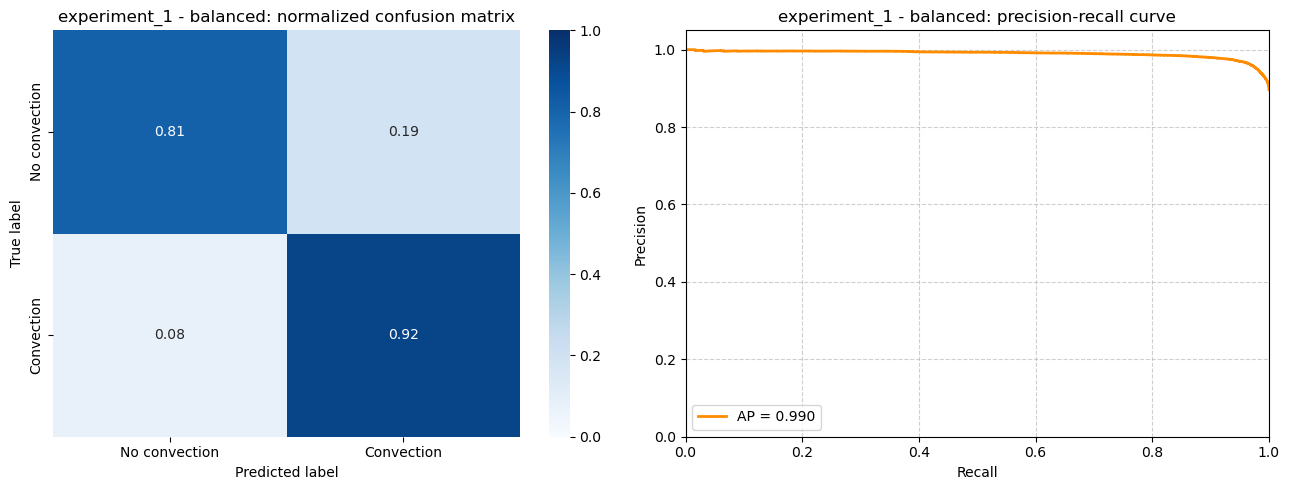

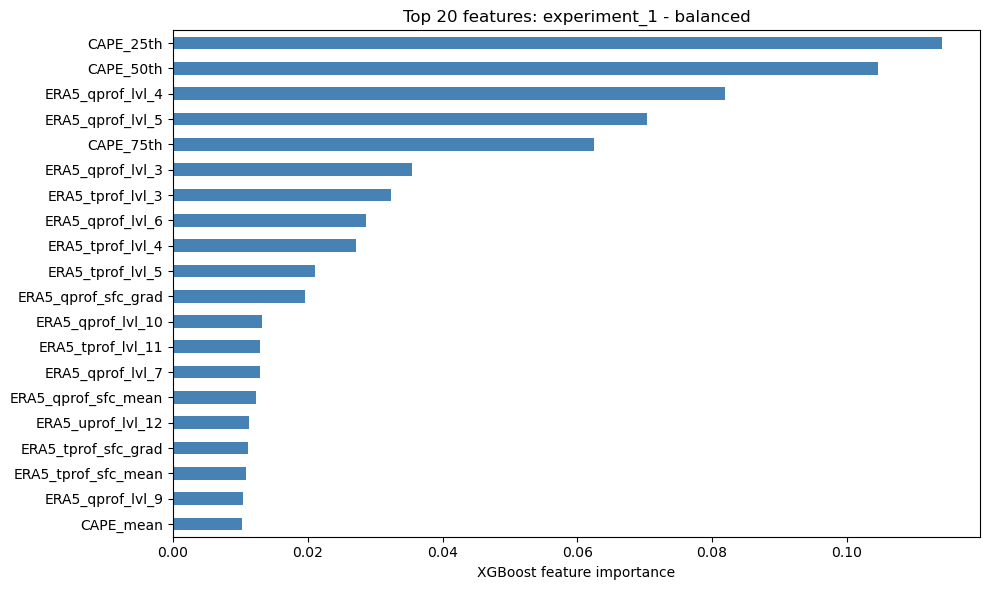

--- XGBoost: experiment_1 - unbalanced ---
scale_pos_weight: 1.000
Confusion Matrix:
[[ 1564  1023]
 [  565 21891]]
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.60      0.66      2587
           1       0.96      0.97      0.96     22456

    accuracy                           0.94     25043
   macro avg       0.84      0.79      0.81     25043
weighted avg       0.93      0.94      0.93     25043

Average Precision Score: 0.9902


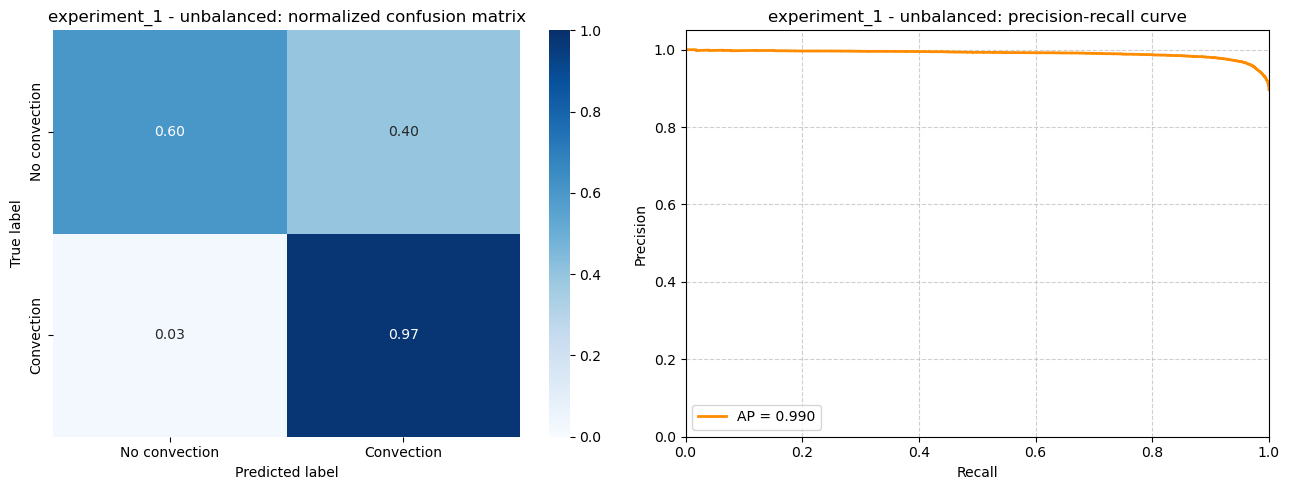

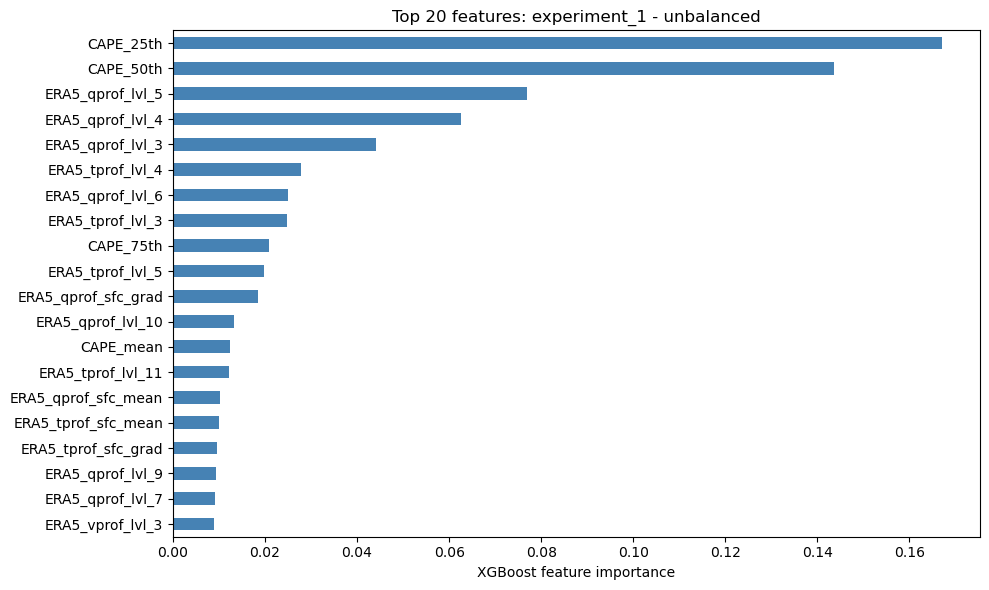

--- XGBoost: experiment_2 - balanced ---
scale_pos_weight: 0.660
Confusion Matrix:
[[ 6314  3702]
 [ 3608 11419]]
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.63      0.63     10016
           1       0.76      0.76      0.76     15027

    accuracy                           0.71     25043
   macro avg       0.70      0.70      0.70     25043
weighted avg       0.71      0.71      0.71     25043

Average Precision Score: 0.8097


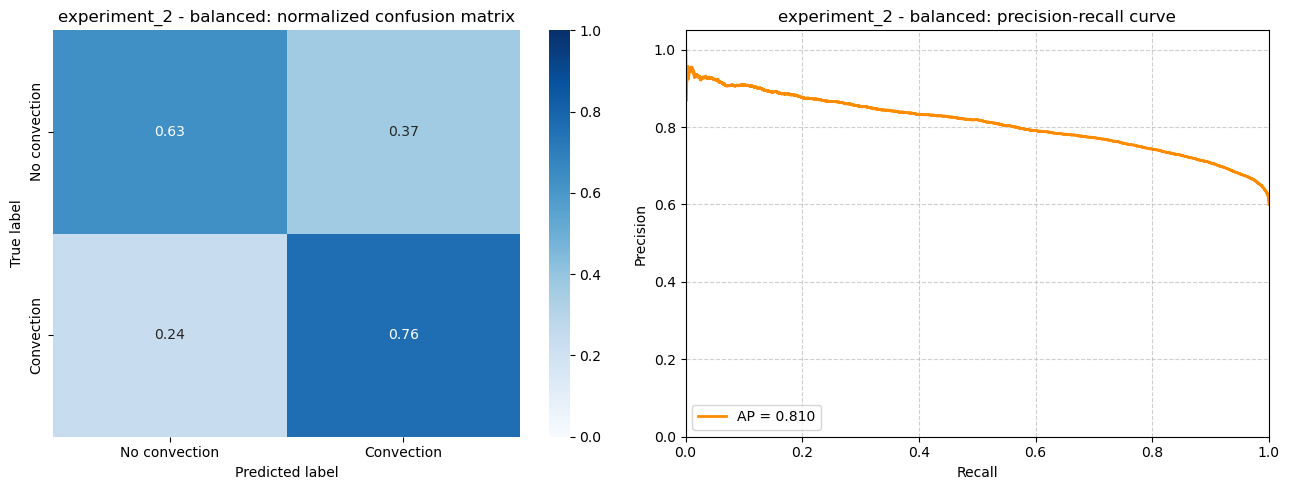

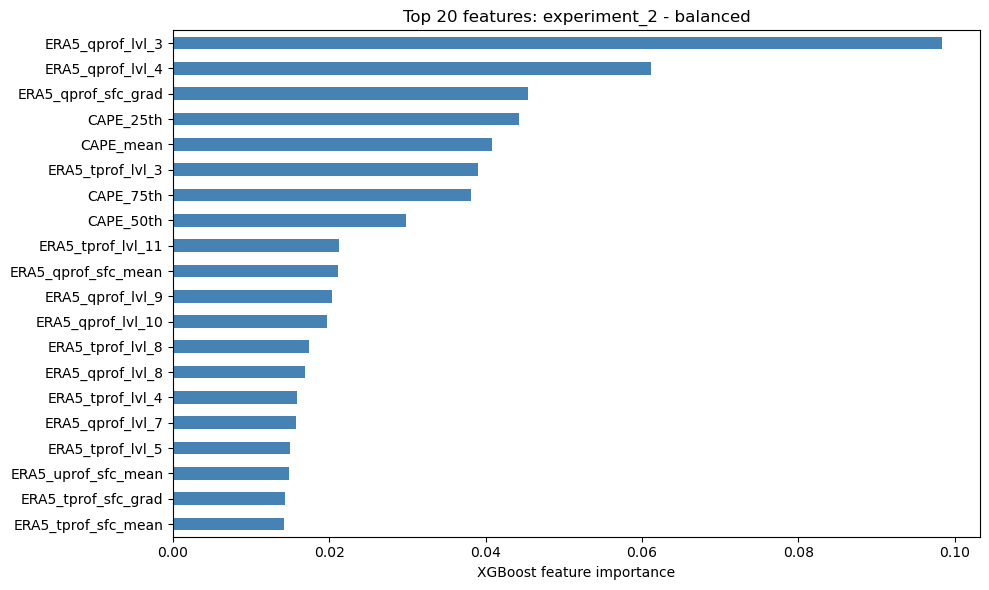

--- XGBoost: experiment_2 - unbalanced ---
scale_pos_weight: 1.000
Confusion Matrix:
[[ 4756  5260]
 [ 1815 13212]]
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.47      0.57     10016
           1       0.72      0.88      0.79     15027

    accuracy                           0.72     25043
   macro avg       0.72      0.68      0.68     25043
weighted avg       0.72      0.72      0.70     25043

Average Precision Score: 0.8097


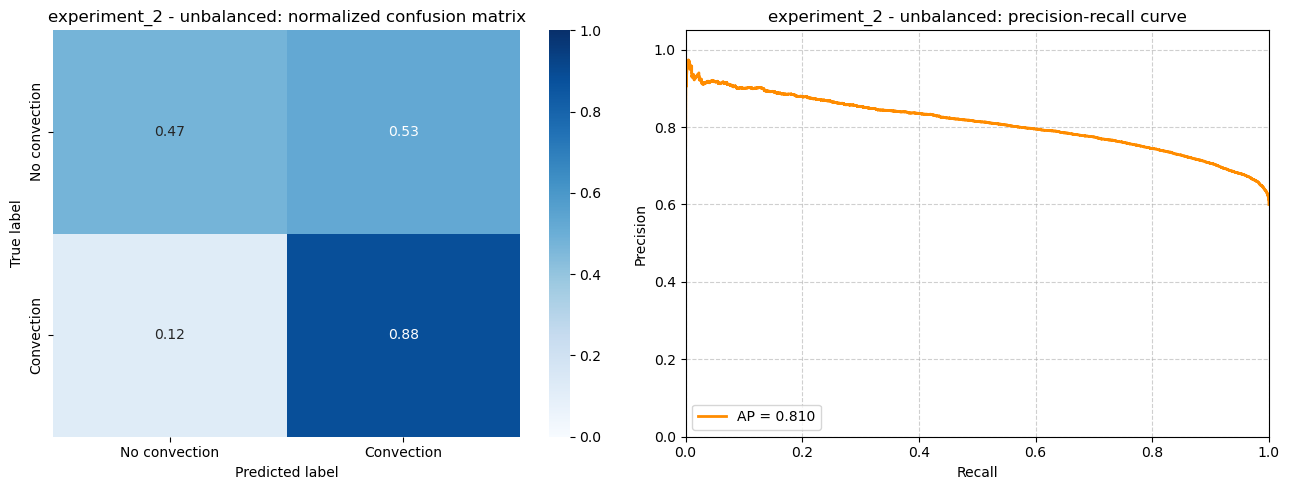

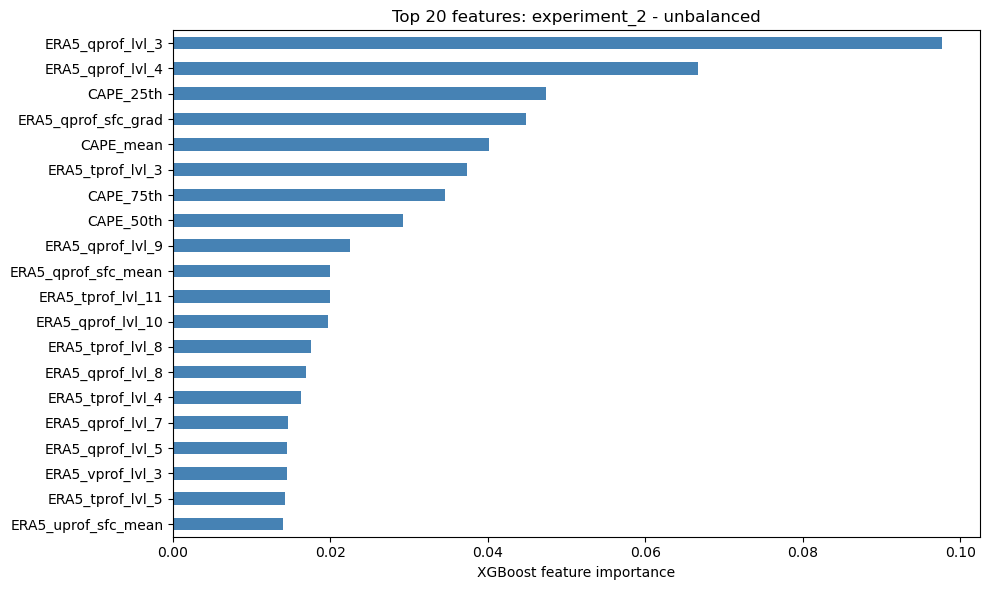

In [6]:
xgb_exp1_balanced = run_xgb_experiment('experiment_1', balanced=True)
xgb_exp1_unbalanced = run_xgb_experiment('experiment_1', balanced=False)
xgb_exp2_balanced = run_xgb_experiment('experiment_2', balanced=True)
xgb_exp2_unbalanced = run_xgb_experiment('experiment_2', balanced=False)

## Find similar environments with different predictions

The analysis below searches the test set for pairs that are close in standardized environmental-feature space but receive opposite predicted labels. It reports the closest pairs, their metadata, prediction probabilities, and the features that differ most.

In [9]:
def find_prediction_contrasts(results, n_cases=5, chunk_size=128, n_candidates=100):
    X_test = results['X_test']
    predictions = pd.Series(results['y_pred'], index=X_test.index, name='Model_prediction')
    scores = pd.Series(results['y_scores'], index=X_test.index, name='Convection_probability')
    truth = pd.Series(results['y_test'], index=X_test.index, name='Observed_target')

    predicted_off = predictions[predictions == 0].index
    predicted_on = predictions[predictions == 1].index
    if predicted_off.empty or predicted_on.empty:
        raise ValueError('The test predictions contain only one predicted class.')

    feature_scale = results['X_train'].std().replace(0, np.nan).fillna(1.0)
    X_scaled = (X_test - results['X_train'].mean()) / feature_scale
    off_values = X_scaled.loc[predicted_off].to_numpy()
    on_values = X_scaled.loc[predicted_on].to_numpy()

    nearest_distances = np.full(len(predicted_off), np.inf)
    nearest_on_positions = np.empty(len(predicted_off), dtype=int)
    for start in range(0, len(predicted_off), chunk_size):
        stop = min(start + chunk_size, len(predicted_off))
        distance_chunk = np.sqrt(((off_values[start:stop, None, :] - on_values[None, :, :]) ** 2).sum(axis=2))
        nearest_positions = distance_chunk.argmin(axis=1)
        nearest_distances[start:stop] = distance_chunk[np.arange(stop - start), nearest_positions]
        nearest_on_positions[start:stop] = nearest_positions

    candidate_positions = np.argsort(nearest_distances)[:n_candidates]
    probability_gaps = np.array([
        abs(scores.loc[predicted_off[position]] - scores.loc[predicted_on[nearest_on_positions[position]]])
        for position in candidate_positions
    ])
    selected_order = np.argsort(probability_gaps)[::-1][:n_cases]
    selected_off_positions = candidate_positions[selected_order]

    pair_rows = []
    pair_tables = {}
    for pair_number, off_position in enumerate(selected_off_positions, start=1):
        on_position = nearest_on_positions[off_position]
        off_index = predicted_off[off_position]
        on_index = predicted_on[on_position]
        off_probability = scores.loc[off_index]
        on_probability = scores.loc[on_index]
        pair_rows.append({
            'Pair': pair_number,
            'Input_distance': nearest_distances[off_position],
            'Probability_gap': abs(off_probability - on_probability),
            'Off_index': off_index,
            'On_index': on_index,
            'Off_date': df_master.loc[off_index, 'Date'],
            'On_date': df_master.loc[on_index, 'Date'],
            'Off_probability': off_probability,
            'On_probability': on_probability,
            'Off_observed_target': truth.loc[off_index],
            'On_observed_target': truth.loc[on_index],
        })

        pair_table = pd.DataFrame({
            'Environmental_variable': X_test.columns,
            'Predicted_off_value': X_test.loc[off_index].to_numpy(),
            'Predicted_on_value': X_test.loc[on_index].to_numpy(),
        })
        pair_table['Absolute_difference'] = (
            pair_table['Predicted_off_value'] - pair_table['Predicted_on_value']
        ).abs()
        pair_table = pair_table.sort_values(
            'Absolute_difference', ascending=False
        ).head(10).reset_index(drop=True)
        pair_table['Predicted_off'] = 'No convection (0)'
        pair_table['Predicted_on'] = 'Convection (1)'
        pair_table['Off_probability'] = off_probability
        pair_table['On_probability'] = on_probability
        pair_tables[pair_number] = pair_table

    pairs = pd.DataFrame(pair_rows)
    display(pairs)
    for pair_number, pair_table in pair_tables.items():
        pair_info = pairs.loc[pairs['Pair'] == pair_number].iloc[0]
        print(
            f"Pair {pair_number}: input distance={pair_info['Input_distance']:.3f}, "
            f"probability gap={pair_info['Probability_gap']:.3f}"
        )
        print(
            f"Predicted-off case: index={pair_info['Off_index']}, "
            f"date={pair_info['Off_date']}, observed={pair_info['Off_observed_target']}"
        )
        print(
            f"Predicted-on case: index={pair_info['On_index']}, "
            f"date={pair_info['On_date']}, observed={pair_info['On_observed_target']}"
        )
        display(pair_table)

    return pairs, pair_tables

contrast_pairs, contrast_tables = find_prediction_contrasts(
    xgb_exp1_balanced,
    n_cases=5,
    n_candidates=100,
)

,Pair,Input_distance,Probability_gap,Off_index,On_index,Off_date,On_date,Off_probability,On_probability,Off_observed_target,On_observed_target
0,1,1.574631,0.915486,83916,83915,20150802,20150802,0.040901,0.956387,1,1
1,2,1.291039,0.914176,99592,99593,20191007,20191007,0.040452,0.954628,0,1
2,3,1.887333,0.911171,102568,102564,20140626,20140626,0.060813,0.971984,0,1
3,4,1.989317,0.907715,89742,89739,20140818,20140818,0.060512,0.968227,0,1
4,5,2.003332,0.897607,29269,29270,20180708,20180708,0.065334,0.962941,1,1


Pair 1: input distance=1.575, probability gap=0.915
Predicted-off case: index=83916, date=20150802, observed=1
Predicted-on case: index=83915, date=20150802, observed=1


,Environmental_variable,Predicted_off_value,Predicted_on_value,Absolute_difference,Predicted_off,Predicted_on,Off_probability,On_probability
0,CAPE_75th,1629.245727,2003.167358,373.921631,No convection (0),Convection (1),0.040901,0.956387
1,CAPE_50th,1446.599064,1807.057617,360.458554,No convection (0),Convection (1),0.040901,0.956387
2,CAPE_mean,1998.802734,1740.518188,258.284546,No convection (0),Convection (1),0.040901,0.956387
3,CAPE_25th,1265.178784,1444.443848,179.265064,No convection (0),Convection (1),0.040901,0.956387
4,ERA5_vprof_lvl_10,-10.857162,-6.901847,3.955315,No convection (0),Convection (1),0.040901,0.956387
5,ERA5_uprof_lvl_11,12.244598,9.951434,2.293164,No convection (0),Convection (1),0.040901,0.956387
6,ERA5_vprof_lvl_6,5.844589,7.841535,1.996946,No convection (0),Convection (1),0.040901,0.956387
7,ERA5_vprof_lvl_9,1.810928,-0.090330,1.901259,No convection (0),Convection (1),0.040901,0.956387
8,ERA5_vprof_lvl_14,3.338150,4.812879,1.474729,No convection (0),Convection (1),0.040901,0.956387
9,ERA5_vprof_lvl_5,6.076279,7.376240,1.299961,No convection (0),Convection (1),0.040901,0.956387


Pair 2: input distance=1.291, probability gap=0.914
Predicted-off case: index=99592, date=20191007, observed=0
Predicted-on case: index=99593, date=20191007, observed=1


,Environmental_variable,Predicted_off_value,Predicted_on_value,Absolute_difference,Predicted_off,Predicted_on,Off_probability,On_probability
0,CAPE_25th,1265.178784,948.988159,316.190625,No convection (0),Convection (1),0.040452,0.954628
1,CAPE_75th,1629.245727,1449.477539,179.768188,No convection (0),Convection (1),0.040452,0.954628
2,CAPE_mean,1334.685791,1227.655640,107.030151,No convection (0),Convection (1),0.040452,0.954628
3,CAPE_50th,1446.599064,1344.127319,102.471744,No convection (0),Convection (1),0.040452,0.954628
4,ERA5_vprof_lvl_9,-4.138952,-0.994827,3.144125,No convection (0),Convection (1),0.040452,0.954628
5,ERA5_vprof_lvl_12,-0.392787,2.487584,2.880371,No convection (0),Convection (1),0.040452,0.954628
6,ERA5_uprof_lvl_10,-7.078979,-4.376750,2.702230,No convection (0),Convection (1),0.040452,0.954628
7,ERA5_uprof_lvl_9,-5.737925,-3.762339,1.975586,No convection (0),Convection (1),0.040452,0.954628
8,ERA5_uprof_lvl_12,-10.478043,-8.693410,1.784633,No convection (0),Convection (1),0.040452,0.954628
9,ERA5_uprof_lvl_13,-1.647776,-3.257640,1.609863,No convection (0),Convection (1),0.040452,0.954628


...

,Environmental_variable,Predicted_off_value,Predicted_on_value,Absolute_difference,Predicted_off,Predicted_on,Off_probability,On_probability
0,CAPE_25th,1265.178784,1651.900879,386.722095,No convection (0),Convection (1),0.060813,0.971984
1,CAPE_50th,1446.599064,1755.682617,309.083554,No convection (0),Convection (1),0.060813,0.971984
2,CAPE_75th,1629.245727,1828.947876,199.702148,No convection (0),Convection (1),0.060813,0.971984
3,CAPE_mean,1601.912781,1725.103516,123.190735,No convection (0),Convection (1),0.060813,0.971984
4,ERA5_vprof_lvl_8,0.916779,-3.154244,4.071023,No convection (0),Convection (1),0.060813,0.971984
5,ERA5_vprof_lvl_7,4.929337,1.309086,3.620250,No convection (0),Convection (1),0.060813,0.971984
6,ERA5_vprof_lvl_12,-3.276581,-6.345140,3.068559,No convection (0),Convection (1),0.060813,0.971984
7,ERA5_uprof_lvl_11,-3.809570,-6.220925,2.411355,No convection (0),Convection (1),0.060813,0.971984
8,ERA5_uprof_sfc_mean,-1.343430,-3.728617,2.385187,No convection (0),Convection (1),0.060813,0.971984
9,ERA5_uprof_lvl_10,-1.928299,-4.194235,2.265936,No convection (0),Convection (1),0.060813,0.971984


Pair 4: input distance=1.989, probability gap=0.908
Predicted-off case: index=89742, date=20140818, observed=0
Predicted-on case: index=89739, date=20140818, observed=1


,Environmental_variable,Predicted_off_value,Predicted_on_value,Absolute_difference,Predicted_off,Predicted_on,Off_probability,On_probability
0,CAPE_mean,1271.421387,1456.336060,184.914673,No convection (0),Convection (1),0.060512,0.968227
1,CAPE_25th,1265.178784,1344.951782,79.772998,No convection (0),Convection (1),0.060512,0.968227
2,CAPE_75th,1629.245727,1588.659546,40.586182,No convection (0),Convection (1),0.060512,0.968227
3,CAPE_50th,1446.599064,1461.583984,14.984921,No convection (0),Convection (1),0.060512,0.968227
4,ERA5_uprof_lvl_10,-9.540955,-4.870393,4.670562,No convection (0),Convection (1),0.060512,0.968227
5,ERA5_vprof_lvl_5,9.325333,5.967672,3.357660,No convection (0),Convection (1),0.060512,0.968227
6,ERA5_uprof_lvl_6,8.755341,11.746191,2.990850,No convection (0),Convection (1),0.060512,0.968227
7,ERA5_vprof_lvl_11,-11.966202,-9.080082,2.886120,No convection (0),Convection (1),0.060512,0.968227
8,ERA5_uprof_lvl_3,9.777557,12.286996,2.509439,No convection (0),Convection (1),0.060512,0.968227
9,ERA5_uprof_sfc_mean,7.719828,10.130767,2.410939,No convection (0),Convection (1),0.060512,0.968227


Pair 5: input distance=2.003, probability gap=0.898
Predicted-off case: index=29269, date=20180708, observed=1
Predicted-on case: index=29270, date=20180708, observed=1


,Environmental_variable,Predicted_off_value,Predicted_on_value,Absolute_difference,Predicted_off,Predicted_on,Off_probability,On_probability
0,CAPE_50th,1446.599064,1937.677612,491.078549,No convection (0),Convection (1),0.065334,0.962941
1,CAPE_75th,1629.245727,2066.447754,437.202026,No convection (0),Convection (1),0.065334,0.962941
2,CAPE_25th,1265.178784,1645.512085,380.333301,No convection (0),Convection (1),0.065334,0.962941
3,CAPE_mean,1973.238586,1863.246094,109.992493,No convection (0),Convection (1),0.065334,0.962941
4,ERA5_vprof_lvl_10,-4.512817,3.437263,7.950080,No convection (0),Convection (1),0.065334,0.962941
5,ERA5_vprof_lvl_11,-4.910980,-0.722233,4.188747,No convection (0),Convection (1),0.065334,0.962941
6,ERA5_uprof_lvl_11,14.072403,17.112970,3.040567,No convection (0),Convection (1),0.065334,0.962941
7,ERA5_vprof_lvl_8,5.497391,8.392156,2.894765,No convection (0),Convection (1),0.065334,0.962941
8,ERA5_uprof_lvl_9,0.610382,3.295945,2.685563,No convection (0),Convection (1),0.065334,0.962941
9,ERA5_uprof_lvl_8,-1.327820,0.878473,2.206293,No convection (0),Convection (1),0.065334,0.962941
